# 04 — Interpretable fluency model + SHAP

Goal: combine the timing features into a single model that predicts human fluency, evaluate
it on the held-out test set, and use SHAP to see how much each feature contributes *jointly*
(not just one-by-one as in the Spearman analysis).

The pause features all had similar individual correlations (ρ ≈ −0.53 to −0.59), which
suggests redundancy — they may all be measuring "this person pauses a lot." SHAP will show
whether a few features carry the signal and the rest are redundant.

In [1]:
import pandas as pd
import numpy as np

# Load the cached feature tables (built in notebook 03) — no recompute needed.
train_feats = pd.read_parquet("../data/train_features.parquet")
test_feats  = pd.read_parquet("../data/test_features.parquet")

# Features that go into the model. We drop onset_latency (ρ = 0.10, barely informative)
# and the context columns (span_time, total_dur) that aren't fluency features per se.
feature_cols = ["speech_rate", "articulation_rate", "phonation_ratio",
                "n_pauses", "pause_time", "pause_ratio", "mean_pause",
                "max_pause", "n_long_pauses"]

X_train, y_train = train_feats[feature_cols], train_feats["fluency"]
X_test,  y_test  = test_feats[feature_cols],  test_feats["fluency"]
print("train:", X_train.shape, "| test:", X_test.shape)

train: (2500, 9) | test: (2500, 9)


In [2]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy.stats import spearmanr

# Ridge on standardized features. Start simple + interpretable; only reach for trees if this
# underperforms (in a past project a linear model beat RF/XGBoost on similar tabular data).
model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
model.fit(X_train, y_train)

# Evaluate by Spearman on the held-out test set (matches our ordinal-target decision).
pred = model.predict(X_test)
rho, p = spearmanr(pred, y_test)
print(f"Test Spearman ρ = {rho:.3f}  (p = {p:.1e})")

Test Spearman ρ = 0.630  (p = 1.1e-276)


In [3]:
# Fair comparison: single best feature vs full model, BOTH on the held-out test set.
rho_sr, _ = spearmanr(test_feats["speech_rate"], y_test)
print(f"speech_rate alone (test): ρ = {rho_sr:.3f}")
print(f"full model       (test): ρ = {rho:.3f}")

speech_rate alone (test): ρ = 0.621
full model       (test): ρ = 0.630


/Users/rnorel/.pyenv/versions/3.11.14/envs/fluency-from-alignment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


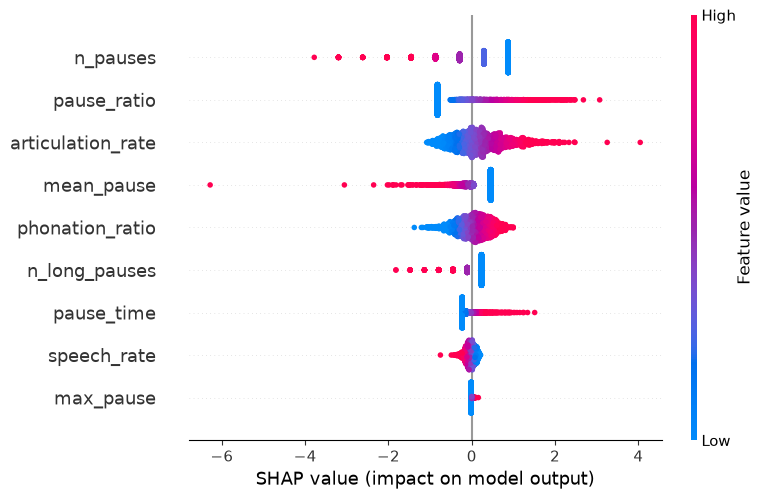

In [5]:
import shap
import matplotlib.pyplot as plt

# SHAP on the Ridge model to see each feature's JOINT contribution.
# Hypothesis: speech_rate dominates; the pause features add little once it's present.
# LinearExplainer is exact and fast for linear models.
ridge = model.named_steps["ridge"]
scaler = model.named_steps["standardscaler"]
X_test_scaled = scaler.transform(X_test)

explainer = shap.LinearExplainer(ridge, scaler.transform(X_train))
shap_values = explainer.shap_values(X_test_scaled)

# Beeswarm: overall feature importance + direction across the test set.
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_cols, show=False)
plt.tight_layout()
plt.savefig("../figures/shap_summary.png", dpi=130, bbox_inches="tight")
plt.show()

### ⚠️ Why we don't rely on this SHAP plot

This SHAP summary is **misleading here, and we keep it as a cautionary example.** It ranks
`speech_rate` low and the pause features high — the opposite of the individual Spearman
correlations, where `speech_rate` was the single strongest predictor (ρ = 0.64).

The cause is **multicollinearity**. The features are highly correlated (the six pause
features reach ρ ≈ 0.99 with each other — see the collinearity heatmap below). With
correlated inputs, a linear model can distribute weight among them almost arbitrarily while
producing the same predictions, so the per-feature attributions don't reflect true
importance — they reflect how the fitting happened to split credit this time.

**Takeaway:** feature-importance methods (SHAP included) are unreliable under severe
collinearity. The correct move is to diagnose the collinearity first (heatmap), then reduce
to independent blocks — which is what the rest of this notebook does. We keep this plot to
document the trap, not because its ranking should be trusted.

## Why the simplest feature wins — and why that matters

A model with all nine timing features (test ρ = 0.630) barely beats **speech_rate alone**
(test ρ = 0.621). The eight other features add ~0.009. Once you know words-per-second,
the pause features are largely redundant — speech_rate already folds pauses in (more
pausing → longer total time → lower rate).

This is not incidental. Speech rate is repeatedly the strongest, most robust fluency
signal across speech-scoring domains, and it has a decisive practical advantage:
non-technical stakeholders understand it. In educational and clinical settings, a score
that affects a student or patient has to be *defensible* — "read at 3 words/sec" is
transparent and trusted; a black-box combination of features is neither. The right
engineering choice is often the interpretable feature that stakeholders can reason about,
not the marginally-better complex one.

In [6]:
# The SHAP result contradicts the individual correlations (speech_rate was strongest alone,
# yet ranks low here). Prime suspect: multicollinearity — with correlated features, a linear
# model splits credit arbitrarily among them, so SHAP importances become unreliable.
# Check the correlation structure among the features themselves.
import numpy as np

corr_matrix = X_train.corr(method="spearman")
print(corr_matrix.round(2).to_string())

                   speech_rate  articulation_rate  phonation_ratio  n_pauses  pause_time  pause_ratio  mean_pause  max_pause  n_long_pauses
speech_rate               1.00               0.86             0.62     -0.73       -0.75        -0.71       -0.71      -0.73          -0.63
articulation_rate         0.86               1.00             0.17     -0.45       -0.46        -0.40       -0.44      -0.45          -0.43
phonation_ratio           0.62               0.17             1.00     -0.77       -0.79        -0.80       -0.75      -0.77          -0.64
n_pauses                 -0.73              -0.45            -0.77      1.00        0.98         0.97        0.91       0.94           0.70
pause_time               -0.75              -0.46            -0.79      0.98        1.00         0.98        0.96       0.98           0.78
pause_ratio              -0.71              -0.40            -0.80      0.97        0.98         1.00        0.95       0.97           0.75
mean_pause          

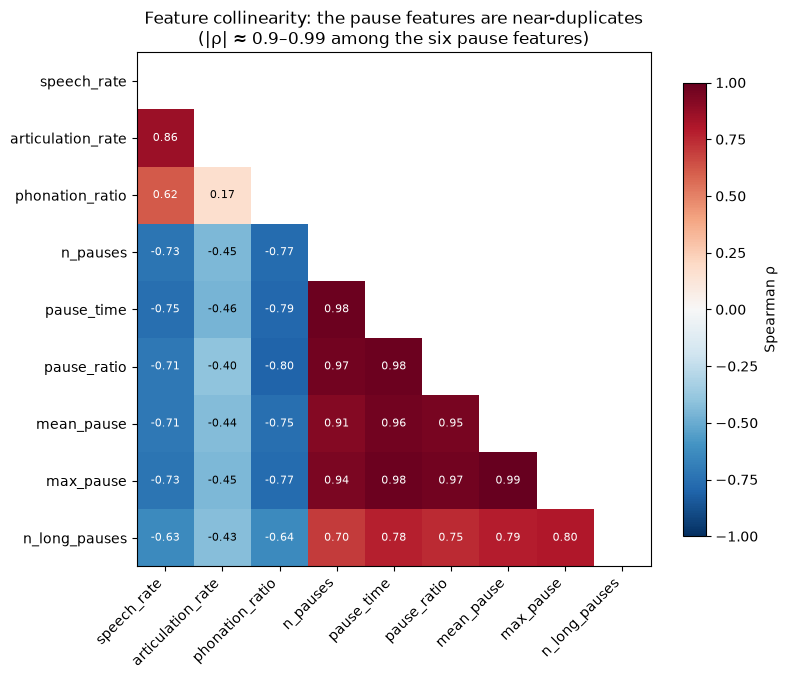

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Lower-triangle-only heatmap: the matrix is symmetric, so we mask the upper triangle
# and the diagonal (all 1.0) to reduce redundancy and make the collinearity blocks clearer.
corr_matrix = X_train.corr(method="spearman")

# Mask = True where we DON'T want to draw (upper triangle including the diagonal).
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))          # k=0 also hides the diagonal
corr_masked = np.ma.masked_where(mask, corr_matrix.values)

fig, ax = plt.subplots(figsize=(8, 7))
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad("white")                                          # masked cells render as white
im = ax.imshow(corr_masked, cmap=cmap, vmin=-1, vmax=1)

ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha="right")
ax.set_yticklabels(feature_cols)

# Annotate only the visible (lower-triangle) cells.
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        if not mask[i, j]:
            val = corr_matrix.iloc[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color="white" if abs(val) > 0.6 else "black", fontsize=8)

fig.colorbar(im, ax=ax, label="Spearman ρ", shrink=0.8)
ax.set_title("Feature collinearity: the pause features are near-duplicates\n"
             "(|ρ| ≈ 0.9–0.99 among the six pause features)")
plt.tight_layout()
plt.savefig("../figures/feature_collinearity_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

## Why reduce to 3 features — and why Ridge didn't do it for us

A natural question: shouldn't Ridge just down-weight the redundant features? No — that's not
what L2 regularization does. Ridge penalizes the sum of *squared* weights, so when features
are highly correlated it prefers to **spread** weight across them rather than concentrate it
in one. That's exactly why the SHAP importances were scattered arbitrarily across the six
near-duplicate pause features: Ridge treated them all as "somewhat important" because
distributing the weight minimizes the penalty.

Lasso (L1) *does* zero out features, but under extreme collinearity it picks one from each
correlated group essentially at random and is unstable to small data changes — fine for
prediction, unreliable for interpretation.

The takeaway: **no linear model resolves interpretation under collinearity this severe**
(|ρ| ≈ 0.9–0.99 among the pause features). Collinearity has to be handled *before* modeling,
using domain judgment. We therefore group the nine features into the ~3 independent blocks
the correlation structure reveals — speed, pausing, phonation — and keep one interpretable
representative of each:

- **Speed** → `speech_rate` (strongest single predictor; the metric non-technical
  stakeholders understand best)
- **Pausing** → one pause feature (the six are near-identical, ρ up to 0.99)
- **Phonation** → `phonation_ratio` (the least correlated with the rest — carries its own signal)

We then verify empirically that the 3-feature model predicts about as well as the 9-feature
one — confirming the other six added little beyond redundancy.

In [9]:
# The main result: does a 3-feature model (one per collinearity block) match the 9-feature one?
# Blocks: speed -> speech_rate, pausing -> n_pauses, phonation -> phonation_ratio.
three = ["speech_rate", "n_pauses", "phonation_ratio"]

model_3 = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
model_3.fit(X_train[three], y_train)
rho_3, _ = spearmanr(model_3.predict(X_test[three]), y_test)

print(f"9-feature model (test): ρ = {rho:.3f}")
print(f"3-feature model (test): ρ = {rho_3:.3f}")
print(f"speech_rate alone (test): ρ = {rho_sr:.3f}")

9-feature model (test): ρ = 0.630
3-feature model (test): ρ = 0.627
speech_rate alone (test): ρ = 0.621


In [10]:
from sklearn.linear_model import Lasso
from sklearn.utils import resample

# Stability check: does Lasso pick a STABLE feature from the collinear pause block,
# or does its choice flip across resamples? Instability here is the empirical proof that
# you can't trust Lasso to interpret which feature matters under severe collinearity.
pause_block = ["n_pauses", "pause_time", "pause_ratio", "mean_pause", "max_pause", "n_long_pauses"]

Xs = StandardScaler().fit_transform(X_train)
Xs = pd.DataFrame(Xs, columns=feature_cols)

winners = []
for seed in range(50):
    Xb, yb = resample(Xs, y_train, random_state=seed)          # bootstrap sample
    lasso = Lasso(alpha=0.1).fit(Xb, yb)
    coefs = pd.Series(np.abs(lasso.coef_), index=feature_cols)
    # Which pause feature got the largest weight this run?
    winners.append(coefs[pause_block].idxmax())

print("How often each pause feature 'won' across 50 resamples:")
print(pd.Series(winners).value_counts())

How often each pause feature 'won' across 50 resamples:
n_pauses         49
n_long_pauses     1
Name: count, dtype: int64
